### ECCOv4r6 budget closure

- Attempting to close the v4r6 budget using the converted netcdf files.
- Using https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Heat_budget_closure.html as reference

AHS


Things I had to change
- hFacC needs to be transposed as .transpose('tile','k','j','i')., if reading the netcdfs without paralell = True

In [1]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           376Gi        91Gi        53Gi        10Gi       251Gi       285Gi
Swap:             0B          0B          0B


In [2]:
import xarray as xr
from dask.distributed import Client
import numpy as np
from pathlib import Path
import ecco_v4_py as ecco
import os
import xgcm
import matplotlib.pyplot as plt

### Loading a dask client

In [3]:
client = Client(
    n_workers=30,
    threads_per_worker=4,
    memory_limit="10GB"
)

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 30
Total threads: 120,Total memory: 279.40 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35527,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42971,Total threads: 4
Dashboard: http://127.0.0.1:46093/status,Memory: 9.31 GiB
Nanny: tcp://127.0.0.1:42567,


2026-03-06 15:42:48,866 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:35319' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('concatenate-5843a8ce7afdfb6ee17fde1998201d8a', 13, 0, 0, 0, 0), ('asanyarray_safe-getitem-bd481a98e36e97bbd19f413ca30b44d1', 0, 0, 0), ('asanyarray_safe-getitem-a1cc4c6724f054f20ba723226386ca56', 0, 0, 0), ('asanyarray_safe-getitem-58a7cdde18156460daedd3a759e78758', 0, 0, 0), ('asanyarray_safe-getitem-3057d25912a980a028276c0148c21c1f', 0, 0, 0), ('getitem-transpose-concatenate-a8a8858ecbaa33763d104b1a4350a8a0', 1, 14, 0, 0, 0), ('asanyarray_safe-getitem-bafc78fa8ff6b777436118d919a350be', 0, 0, 0), ('asanyarray_safe-getitem-b94c548057987a57d25338fd7497190f', 0, 0, 0), ('getitem-25c7ab14753f19b10121ab4d4b363027', 7, 0, 0, 0, 0), ('asanyarray_safe-getitem-0391c17c1c9c8bb72b131608da96e10e', 0, 0, 0), ('getitem-25c7ab14753f19b10121ab4d4b363027', 9, 0, 0, 0, 0), ('asanyarray_safe-getitem-b6cc03fd5c774b7

In [4]:
# client.close()

### Load the grid

In [41]:
grid = xr.open_dataset('/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/GRID_GEOMETRY_ECCO_V4r5_native_llc0090.nc')
grid

<xarray.Dataset> Size: 92MB
Dimensions:                 (tile: 13, j: 90, i: 90, j_g: 90, i_g: 90,
                             k_p1: 51, k: 50, k_u: 50, k_l: 50, nbh: 4, nv: 2)
Coordinates: (12/20)
  * tile                    (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j                       (j) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
  * i                       (i) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
    XC                      (tile, j, i) float32 421kB ...
    YC                      (tile, j, i) float32 421kB ...
  * j_g                     (j_g) int32 360B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89
    ...                      ...
    Zu                      (k_u) float32 200B ...
  * k_l                     (k_l) int32 200B 0 1 2 3 4 5 6 ... 44 45 46 47 48 49
    Zl                      (k_l) float32 200B ...
    XC_bnds                 (tile, j, i, nbh) float32 2MB ...
    YC_bnds                 (tile, j, i, nbh) float32 2MB ...
    Z_bnds                  (k, nv) float32 400B ...
Dimensions without coordinates: nbh, nv
Data variables: (12/29)
    CS                      (tile, j, i) float32 421kB ...
    SN                      (tile, j, i) float32 421kB ...
    rA                      (tile, j, i) float32 421kB ...
    dxG                     (tile, j_g, i) float32 421kB ...
    dyG                     (tile, j, i_g) float32 421kB ...
    Depth                   (tile, j, i) float32 421kB ...
    ...                      ...
    dyF                     (tile, j, i) float32 421kB ...
    dyU                     (tile, j_g, i_g) float32 421kB ...
    rLowC                   (tile, j, i) float32 421kB ...
    rSurfC                  (tile, j, i) float32 421kB ...
    ocean_column_thickness  (tile, j, i) float32 421kB ...
    ice_shelf_draft         (tile, j, i) float32 421kB ...
Attributes: (12/61)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty, Ou Wang, Ichiro Fukumori
    cdm_data_type:                   Grid
    comment:                         Fields provided on the curvilinear lat-l...
    Conventions:                     CF-1.8, ACDD-1.3
    creator_email:                   ecco-group@mit.edu
    ...                              ...
    source:                          The ECCO state estimate was produced by ...
    standard_name_vocabulary:        NetCDF Climate and Forecast (CF) Metadat...
    summary:                         This dataset provides geometric paramete...
    title:                           ECCO Geometry Parameters - llc90 Grid (V...
    uuid:                            ef749a0c-e985-11ed-a16e-0242ac110002
    coordinates_comment:             Note: the global 'coordinates' attribute...

### Volume
Calculate the volume of each grid cell. This is used when converting advective and diffusive flux convergences and calculating volume-weighted averages.

In [42]:
# Volume (m^3)
vol = (grid.rA*grid.drF*grid.hFacC).transpose('tile','k','j','i')#.compute()
vol

# no need to .compute, the grid file is already loaded to memory

<xarray.DataArray (tile: 13, k: 50, j: 90, i: 90)> Size: 21MB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [3.36366920e+10, 3.36366920e+10, 3.36366920e+10, ...,
          3.36366920e+10, 3.36366920e+10, 3.36366920e+10],
         [3.46319831e+10, 3.46319831e+10, 3.46319831e+10, ...,
          3.46319831e+10, 3.46319831e+10, 3.46319831e+10],
         [3.54426675e+10, 3.54426675e+10, 3.54426675e+10, ...,
          3.54426675e+10, 3.54426675e+10, 3.54426675e+10]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]]],
      shape=(13, 50, 90, 90), dtype=float32)
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
Attributes:
    coordinate:             YC XC
    coverage_content_type:  modelResult
    long_name:              vertical open fraction of tracer grid cell
    units:                  1

In [43]:
vol.nbytes*1e-6

21.06

### Load monthly snapshots

In [44]:
etan_dir = Path('/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/ETAN_mon_snap/')
theta_dir = Path('/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/')

In [45]:
etan_files = np.sort(list(etan_dir.glob('*nc')))
theta_files = np.sort(list(theta_dir.glob('*nc')))

In [46]:
%%time
# year_start = 1993
# year_end = 2019

# open ETAN and THETA snapshots (beginning of each month)
ecco_monthly_SSH = xr.open_mfdataset(
    etan_files,
    parallel=False,   # ← temporarily disable
    data_vars=['ETAN'],
    coords='minimal',
    compat='override',
    combine='by_coords',
    chunks={
        'time': 12,
        'tile': 13,
        'j': 90,
        'i': 90
    }
)

ecco_monthly_theta = xr.open_mfdataset(
    theta_files,
    parallel=False,   # ← temporarily disable
    data_vars=['THETA'],
    coords='minimal',
    compat='override',
    combine='by_coords',
    chunks={
        'time': 12,
        'tile': 13,
        'j': 90,
        'i': 90
    }
)

ecco_monthly_snaps = xr.merge((ecco_monthly_SSH['ETAN'],ecco_monthly_theta['THETA']))

# # time mask for snapshots
# time_snap_mask = np.logical_and(ecco_monthly_snaps.time.values >= np.datetime64(str(year_start)+'-01-01','ns'),\
#                                 ecco_monthly_snaps.time.values < np.datetime64(str(year_end+1)+'-01-02','ns'))

# ecco_monthly_snaps = ecco_monthly_snaps.isel(time=time_snap_mask)

CPU times: user 1.43 s, sys: 1.02 s, total: 2.46 s
Wall time: 5.06 s


In [47]:
ecco_monthly_snaps

<xarray.Dataset> Size: 8GB
Dimensions:  (tile: 13, j: 90, i: 90, time: 395, k: 50)
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * time     (time) datetime64[ns] 3kB 1992-01-01 1992-02-01 ... 2024-11-01
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
Data variables:
    ETAN     (time, tile, j, i) float32 166MB dask.array<chunksize=(12, 13, 90, 90), meta=np.ndarray>
    THETA    (time, k, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>

In [48]:
# 1992-01 (beginning of first month) to 2025-01-01 (end of last month, 2024-12)
print(ecco_monthly_snaps.ETAN.time.isel(time=[0, -1]).values)

['1992-01-01T00:00:00.000000000' '2024-11-01T00:00:00.000000000']


In [49]:
# Find the record of the last snapshot
## This is used to defined the exact period for monthly mean data 
last_record_date = ecco.extract_yyyy_mm_dd_hh_mm_ss_from_datetime64(ecco_monthly_snaps.time[-1].values)
print(last_record_date)

(2024, 11, 1, 0, 0, 0)


### Load monthly mean data 

In [50]:
base_path = "/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf"

In [51]:
def open_ecco_var(varname):

    var_path = os.path.join(base_path, varname)

    files = sorted(
        os.path.join(var_path, f)
        for f in os.listdir(var_path)
        if f.endswith(".nc")
    )

    # open one file to inspect dims
    ds_tmp = xr.open_dataset(files[0])

    # default chunk targets
    target_chunks = {
        "time": 12,
        "tile": 13,
        "k": 50,
        "k_l": 50,
        "j": 90,
        "j_g": 90,
        "i": 90,
        "i_g": 90
    }

    # keep only dims that exist in this dataset
    chunks = {d: target_chunks[d] for d in ds_tmp.dims if d in target_chunks}

    ds = xr.open_mfdataset(
        files,
        parallel=False,
        coords="minimal",
        compat="override",
        combine="by_coords",
        chunks=chunks
    )

    return ds

In [52]:
%%time

var_names = [
    "ADVr_TH_mon_mean", "ADVy_TH_mon_mean", "ADVx_TH_mon_mean",
    "TFLUX_mon_mean", "oceQsw_mon_mean",
    "DFrI_TH_mon_mean", "DFyE_TH_mon_mean", "DFrE_TH_mon_mean", "DFxE_TH_mon_mean"
]
datasets = [open_ecco_var(v) for v in var_names]

CPU times: user 6.81 s, sys: 1.89 s, total: 8.7 s
Wall time: 19.5 s


In [53]:
ecco_monthly_mean = xr.merge(datasets)

/tmp/ipykernel_1812501/271638610.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ecco_monthly_mean = xr.merge(datasets)
/tmp/ipykernel_1812501/271638610.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ecco_monthly_mean = xr.merge(datasets)


In [55]:
ecco_monthly_mean

<xarray.Dataset> Size: 59GB
Dimensions:  (time: 396, k_l: 50, tile: 13, j: 90, i: 90, k: 50, j_g: 90,
              i_g: 90)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-12-15
  * k_l      (k_l) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Zl       (k_l) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * j_g      (j_g) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g      (i_g) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Data variables:
    ADVr_TH  (time, k_l, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    ADVy_TH  (time, k, tile, j_g, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    ADVx_TH  (time, k, tile, j, i_g) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    TFLUX    (time, tile, j, i) float32 167MB dask.array<chunksize=(12, 13, 90, 90), meta=np.ndarray>
    oceQsw   (time, tile, j, i) float32 167MB dask.array<chunksize=(12, 13, 90, 90), meta=np.ndarray>
    DFrI_TH  (time, k_l, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    DFyE_TH  (time, k, tile, j_g, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    DFrE_TH  (time, k_l, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    DFxE_TH  (time, k, tile, j, i_g) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>

In [56]:
ecco_monthly_mean = ecco_monthly_mean.isel(time=slice(None,-2))

In [57]:
# Print first and last time points of the monthly-mean records
print(ecco_monthly_mean.time.isel(time=[0, -1]).values)

['1992-01-15T00:00:00.000000000' '2024-10-15T00:00:00.000000000']


Each monthly mean record is bookended by a snapshot. We should have one more snapshot than monthly mean record.

In [58]:
print('Number of monthly mean records: ', len(ecco_monthly_mean.time))
print('Number of monthly snapshot records: ', len(ecco_monthly_snaps.time))

Number of monthly mean records:  394
Number of monthly snapshot records:  395


### Merge dataset of monthly mean and snapshots data
Merge the two datasets to put everything into one single dataset

In [59]:
ds = xr.merge([ecco_monthly_mean,
               ecco_monthly_snaps.rename({'time':'time_snp','ETAN':'ETAN_snp', 'THETA':'THETA_snp'})])

/tmp/ipykernel_1812501/608360790.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ecco_monthly_mean,


In [60]:
ds

<xarray.Dataset> Size: 67GB
Dimensions:    (time: 394, k_l: 50, tile: 13, j: 90, i: 90, k: 50, j_g: 90,
                i_g: 90, time_snp: 395)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * k_l        (k_l) int32 200B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
    Zl         (k_l) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * tile       (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j          (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i          (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k          (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z          (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * j_g        (j_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * i_g        (i_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time_snp   (time_snp) datetime64[ns] 3kB 1992-01-01 ... 2024-11-01
Data variables:
    ADVr_TH    (time, k_l, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    ADVy_TH    (time, k, tile, j_g, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    ADVx_TH    (time, k, tile, j, i_g) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    TFLUX      (time, tile, j, i) float32 166MB dask.array<chunksize=(12, 13, 90, 90), meta=np.ndarray>
    oceQsw     (time, tile, j, i) float32 166MB dask.array<chunksize=(12, 13, 90, 90), meta=np.ndarray>
    DFrI_TH    (time, k_l, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    DFyE_TH    (time, k, tile, j_g, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    DFrE_TH    (time, k_l, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    DFxE_TH    (time, k, tile, j, i_g) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>
    ETAN_snp   (time_snp, tile, j, i) float32 166MB dask.array<chunksize=(12, 13, 90, 90), meta=np.ndarray>
    THETA_snp  (time_snp, k, tile, j, i) float32 8GB dask.array<chunksize=(12, 50, 13, 90, 90), meta=np.ndarray>

### Create the xgcm 'grid' object

The `xgcm` 'grid' object is used to calculate the flux divergences across different tiles of the lat-lon-cap grid and the time derivatives from ``THETA`` snapshots

In [61]:
# Change time axis of the snapshot variables
ds.time_snp.attrs['c_grid_axis_shift'] = 0.5

In [62]:
# Create a dictionary mapping ECCO grid coords to xgcm axes
coords = {
    'X': {'center': 'i', 'left': 'i_g'},
    'Y': {'center': 'j', 'left': 'j_g'},
    'Z': {'center': 'k', 'left': 'k_l', 'right': 'k_u', 'outer': 'k_p1'},
    'T': {'center': 'time', 'outer': 'time_snp'}  }

ecco_grid = xgcm.Grid(
    ds.assign_coords(coords=grid.coords),
    coords=coords,
    periodic=False,
    boundary=None,
    autoparse_metadata=False
)
ecco_grid

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center
Z Axis (not periodic, boundary='fill'):
  * center   k --> left
  * left     k_l --> center
  * right    k_u --> center
  * outer    k_p1 --> center
T Axis (not periodic, boundary='fill'):
  * center   time --> outer
  * outer    time_snp --> center

### Number of seconds in each month
The xgcm `grid` object includes information on the time axis, such that we can use it to get $\Delta t$, which is the time span between the beginning and end of each month (in seconds).

In [63]:
delta_t = ecco_grid.diff(ds.time_snp, 'T', boundary='fill', fill_value=np.nan)

# Convert to seconds
delta_t = delta_t.astype('f4') / 1e9

In [64]:
delta_t

<xarray.DataArray 'time_snp' (time: 394)> Size: 2kB
array([2.6784e+06, 2.5056e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.4192e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.4192e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.4192e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5056e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.6784e+06, 2.4192e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.4192e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.4192e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.5056e+06, 2.6784e+06, 2.5920e+06,
...
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.6784e+06, 2.4192e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.4192e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.4192e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.5056e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06, 2.4192e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.6784e+06, 2.4192e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.6784e+06, 2.4192e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.5920e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.6784e+06,
       2.5056e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06, 2.5920e+06,
       2.6784e+06, 2.6784e+06, 2.5920e+06, 2.6784e+06], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
Attributes:
    c_grid_axis_shift:  0.5

### Add relevant constants

In [65]:
# Seawater density (kg/m^3)
rhoconst = 1029
## needed to convert surface mass fluxes to volume fluxes

# Heat capacity (J/kg/K)
c_p = 3994

# Constants for surface heat penetration (from Table 2 of Paulson and Simpson, 1977)
R = 0.62 
zeta1 = 0.6
zeta2 = 20.0

## Calculate total tendency of $\theta$ ($G^{\theta}_\textrm{total}$)

We calculate the monthly-averaged time tendency of ``THETA`` by differencing monthly ``THETA`` snapshots. Remember  that we need to include a scaling factor due to the nonlinear free surface formulation. Thus, we need to use snapshots of both `ETAN` and `THETA`  to evaluate $s^*\theta$.

In [66]:
# Calculate the s*theta term
sTHETA = ds.THETA_snp*(1+ds.ETAN_snp/grid.Depth)

In [67]:
# Total tendency (psu/s)
G_total = sTHETA.diff(dim='time_snp')/np.expand_dims(delta_t.values,axis=(1,2,3,4))

# re-assign and rename time coordinate
G_total = G_total.rename({'time_snp':'time'})
G_total = G_total.assign_coords({'time':delta_t.time.values})

In [68]:
G_total

<xarray.DataArray (time: 394, k: 50, tile: 13, j: 90, i: 90)> Size: 8GB
dask.array<truediv, shape=(394, 50, 13, 90, 90), dtype=float32, chunksize=(11, 50, 13, 90, 90), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB ...
    YC       (tile, j, i) float32 421kB ...
Attributes:
    long_name:              model seafloor depth below ocean surface at rest
    units:                  m
    coordinate:             XC YC
    coverage_content_type:  modelResult
    standard_name:          sea_floor_depth_below_geoid
    comment:                Model seafloor depth corresponds to mean ocean de...

> **Note**: Unlike the monthly snapshots `ETAN_snp` and `THETA_snp`, the resulting data array `G_total` has now the same time values as the time-mean fields (middle of the month).

### Plot the time-mean $\partial \theta / \partial t$, total $\Delta \theta$, and one example $\partial \theta / \partial t$ field

####  Time-mean $\partial \theta / \partial t$
The time-mean $\partial \theta / \partial t$ (i.e., $\overline{G^{\theta}_\textrm{total}}$), is given by 

$\overline{G^{\theta}_\textrm{total}} = \sum_{i=1}^{nm} w_i G^{\theta}_\textrm{total}$

with $\sum_{i=1}^{nm} w_i = 1$ and  nm=number of months

In [69]:
# The weights are just the number of seconds per month divided by total seconds
month_length_weights = delta_t / delta_t.sum()

In [70]:
# The weighted mean weights by the length of each month (in seconds)
G_total_mean = (G_total*month_length_weights).sum('time')#.compute()

In [71]:
# plt.figure(figsize=(15,15))

# for idx, k in enumerate([0,10,25]):
#     p = ecco.plot_proj_to_latlon_grid(ecco_grid.XC, ecco_grid.YC, G_total_mean.isel(k=k),show_colorbar=True,
#                                       cmap='RdBu_r', user_lon_0=-67, dx=2, dy=2, subplot_grid=[3,1,idx+1]);
#     p[1].set_title(r'$\overline{G^\theta_{total}}$ at z = %i m (k = %i) [$^\circ$C s$^{-1}$]'\
#                    %(np.round(-ecco_grid.Z[k].values),k), fontsize=16)

#### Total $\Delta \theta$

How much did ``THETA`` change over the analysis period?

In [72]:
# The number of seconds in the entire period 
seconds_in_entire_period = \
    float(ds.time_snp[-1] - ds.time_snp[0])/1e9
print ('seconds in analysis period: ', seconds_in_entire_period)

# which is also the sum of the number of seconds in each month
print('Sum of seconds in each month ', delta_t.sum().values)

seconds in analysis period:  1036195200.0
Sum of seconds in each month  1.0361952e+09


In [73]:
THETA_delta = G_total_mean*seconds_in_entire_period

/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered

CPU times: user 6.16 s, sys: 1.74 s, total: 7.9 s
Wall time: 2min 39s


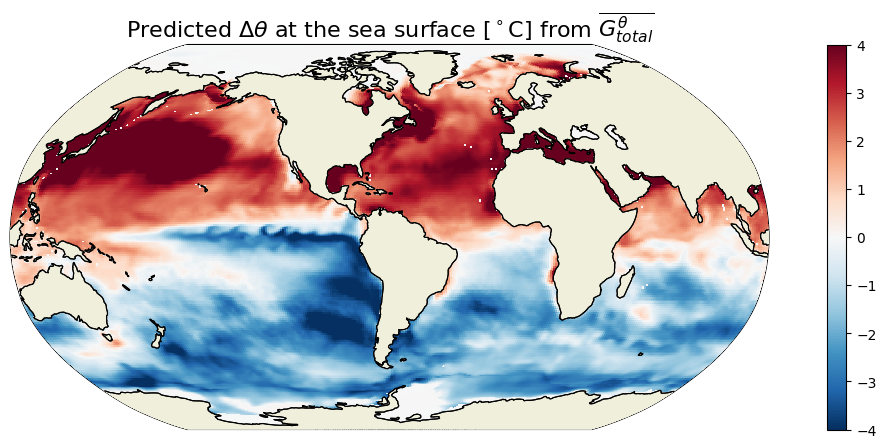

In [74]:
%%time
    
plt.figure(figsize=(15,5));
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, \
                              THETA_delta.isel(k=0),show_colorbar=True,\
                              cmin=-4, cmax=4, \
                              cmap='RdBu_r', user_lon_0=-67, dx=0.2, dy=0.2);
plt.title(r'Predicted $\Delta \theta$ at the sea surface [$^\circ$C] from $\overline{G^\theta_{total}}$',fontsize=16);

We can sanity check the total ``THETA`` change that we found by multipling the time-mean ``THETA`` tendency with the number of seconds in the simulation by comparing that with the difference in ``THETA`` between the end of the last month and start of the first month. 

In [75]:
THETA_delta_method_2 = ds.THETA_snp.isel(time_snp=-1) - ds.THETA_snp.isel(time_snp=0)

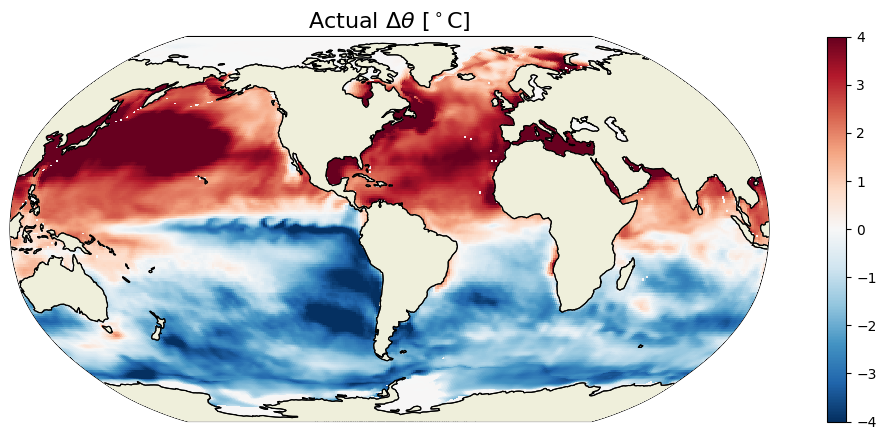

In [76]:
plt.figure(figsize=(15,5));
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, \
                              THETA_delta_method_2.isel(k=0),show_colorbar=True,\
                              cmin=-4, cmax=4, \
                              cmap='RdBu_r', user_lon_0=-67, dx=0.2, dy=0.2);
plt.title(r'Actual $\Delta \theta$ [$^\circ$C]', fontsize=16);

#### Example $G^\theta_{total}$ field at a particular time

In [77]:
# get an array of YYYY, MM, DD, HH, MM, SS for 
#dETAN_dT_perSec at time index 100
curr_t_ind = 100
tmp = str(G_total.time.values[curr_t_ind])
print(tmp)

2000-05-15T00:00:00.000000000


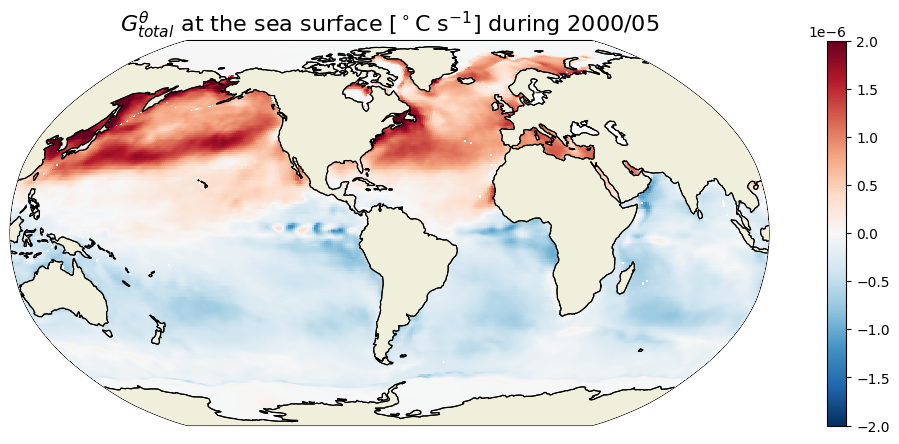

In [78]:
plt.figure(figsize=(15,5));
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, G_total.isel(time=curr_t_ind,k=0), show_colorbar=True,
                              cmap='RdBu_r', user_lon_0=-67, dx=0.2, dy=0.2, cmin=-2e-6, cmax=2e-6);

plt.title(r'$G^\theta_{total}$ at the sea surface [$^\circ$C s$^{-1}$] during ' + 
          str(tmp)[0:4] +'/' + str(tmp)[5:7], fontsize=16);

For any given month the time rate of change of ``THETA`` is strongly dependent on the season. In the above we are looking at May 2001. We see positive ``THETA`` tendency in the northern hemisphere and cooling in the southern hemisphere.

## Calculate tendency due to advective convergence ($G^{\theta}_\textrm{advection}$)

The relevant fields from the diagnostic output here are
- `ADVx_TH`: U Component Advective Flux of Potential Temperature (degC m^3/s)
- `ADVy_TH`: V Component Advective Flux of Potential Temperature (degC m^3/s)
- `ADVr_TH`: Vertical Advective Flux of Potential Temperature (degC m^3/s)

The xgcm `grid` object is then used to take the convergence of the horizontal heat advection.

> **Note**: when using at least one recent version of `xgcm` (v0.8.1), errors were triggered when calling `diff_2d_vector`.
> As an alternative, the `diff_2d_flux_llc90` function is included below.

> **Note**: For the vertical fluxes `ADVr_TH`, `DFrE_TH`, and `DFrI_TH`, we need to make sure that sequence of dimensions are consistent.
> When loading the fields use `.transpose('time','tile','k_l','j','i')`. Otherwise, the divergences will be not correct (at least for `tile = 12`).

In [79]:
def da_replace_at_indices(da,indexing_dict,replace_values):
    # replace values in xarray DataArray using locations specified by indexing_dict
    array_data = da.data
    indexing_dict_bynum = {}
    for axis,dim in enumerate(da.dims):
        if dim in indexing_dict.keys():
            indexing_dict_bynum = {**indexing_dict_bynum,**{axis:indexing_dict[dim]}}
    ndims = len(array_data.shape)
    indexing_list = [':']*ndims
    for axis in indexing_dict_bynum.keys():
        indexing_list[axis] = indexing_dict_bynum[axis]
    indexing_str = ",".join(indexing_list)

    # using exec isn't ideal, but this works for both NumPy and Dask arrays
    exec('array_data['+indexing_str+'] = replace_values')        
    
    return da


def diff_2d_flux_llc90(flux_vector_dict):
    """
    A function that differences flux variables on the llc90 grid.
    Can be used in place of xgcm's diff_2d_vector.
    """

    u_flux = flux_vector_dict['X']
    v_flux = flux_vector_dict['Y']
    
    u_flux_padded = u_flux.pad(pad_width={'i_g':(0,1)},mode='constant',constant_values=np.nan)\
                            .chunk({'i_g':u_flux.sizes['i_g']+1})
    v_flux_padded = v_flux.pad(pad_width={'j_g':(0,1)},mode='constant',constant_values=np.nan)\
                            .chunk({'j_g':v_flux.sizes['j_g']+1})
    
    
    # u flux padding
    for tile in range(0,3):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+3,i_g=0).data)
    for tile in range(3,6):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              v_flux.isel(tile=12-tile,j_g=0,i=slice(None,None,-1)).data)
    u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':'6','i_g':'-1'},\
                                          u_flux.isel(tile=7,i_g=0).data)
    for tile in range(7,9):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)
    for tile in range(10,12):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)
        
    # v flux padding
    for tile in range(0,2):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'2','j_g':'-1'},\
                                          u_flux.isel(tile=6,j=slice(None,None,-1),i_g=0).data)
    for tile in range(3,6):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'6','j_g':'-1'},\
                                          u_flux.isel(tile=10,j=slice(None,None,-1),i_g=0).data)
    for tile in range(7,10):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+3,j_g=0).data)
    for tile in range(10,13):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              u_flux.isel(tile=12-tile,j=slice(None,None,-1),i_g=0).data)
    
    # take differences
    diff_u_flux = u_flux_padded.diff('i_g')
    diff_v_flux = v_flux_padded.diff('j_g')
    
    # include coordinates of input DataArrays and correct dimension/coordinate names
    diff_u_flux = diff_u_flux.assign_coords(u_flux.coords).rename({'i_g':'i'})
    diff_v_flux = diff_v_flux.assign_coords(v_flux.coords).rename({'j_g':'j'})

    diff_flux_vector_dict = {'X':diff_u_flux,'Y':diff_v_flux}
    
    return diff_flux_vector_dict

> **A note about memory usage**: Since the advection and diffusion calculations involve the full-depth ocean and are therefore memory intensive, we are going to be careful about limiting our memory usage at any given time: chunking our data in blocks that are sized based on our available memory, and clearing those blocks of data from our working memory space when we have finished computations with them. This is a little more complicated when using `Python` and `xarray` vs. some other computing languages, but here is the procedure we use:
> - Close the *first* dataset where the data are loaded from source files
> - Re-open the dataset so we clear any previously cached data (both the close and re-open seem to be necessary to clear the cache)
> - Carry out computations
> - Use `del` to delete any data variables where data was previously loaded using `compute`
> - Close the first dataset and repeat the cycle on the next loop iteration

> To make re-opening the dataset quicker, we will use a `pickle` object which saves the pointers created when calling `open_mfdataset` into memory. This is an important time-saver since we will be closing and re-opening this dataset a lot. For more background on why this procedure is being used, see the [Memory management in Python](https://ecco-v4-python-tutorial.readthedocs.io/Memory_management.html) tutorial.

In [80]:
# Set fluxes on land to zero (instead of NaN)
ds['ADVx_TH'] = ds.ADVx_TH.where(grid.hFacW.values > 0,0)
ds['ADVy_TH'] = ds.ADVy_TH.where(grid.hFacS.values > 0,0)
ds['ADVr_TH'] = ds.ADVr_TH.where(grid.hFacC.values > 0,0)

# transpose dimensions for xgcm (see note below)
ds['ADVr_TH'] = ds.ADVr_TH.transpose('time','tile','k_l','j','i')

# re-chunk arrays for better performance
ds['ADVx_TH'] = ds['ADVx_TH'].chunk({'time':1,'k':-1,'tile':-1,'j':-1,'i_g':-1})
ds['ADVy_TH'] = ds['ADVy_TH'].chunk({'time':1,'k':-1,'tile':-1,'j_g':-1,'i':-1})
ds['ADVr_TH'] = ds['ADVr_TH'].chunk({'time':1,'tile':-1,'k_l':-1,'j':-1,'i':-1})


# create pickled object with pointers to original flux files
import pickle
ecco_monthly_mean_pickled = pickle.dumps(ecco_monthly_mean)

# close ecco_vars_int dataset
ecco_monthly_mean.close()

> **Note**: In case of the volume budget (and salinity conservation), the surface forcing (`oceFWflx`) is already included at the top level (`k_l = 0`) in ``WVELMASS``.  Thus, to keep the surface forcing term explicitly represented, one needs to zero out the values of ``WVELMASS`` at the surface so as to avoid double counting (see the [Volume budget closure](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Volume_budget_closure.html) tutorial). This is not the case for the heat budget. `ADVr_TH` does not include the sea surface forcing. Thus, the vertical advective flux (at the air-sea interface) should not be zeroed out.

In [81]:
### Original code to compute G_advection is commented below
### (can use this if xgcm.diff_2d_vector is working properly
### and memory constraints allow)


# # compute horizontal components of flux divergence
# ADVxy_diff = grid.diff_2d_vector({'X' : ds.ADVx_TH, 'Y' : ds.ADVy_TH}, boundary = 'fill')

# # Convergence of horizontal advection (degC m^3/s)
# adv_hConvH = (-(ADVxy_diff['X'] + ADVxy_diff['Y']))

# # Convergence of vertical advection (degC m^3/s)
# adv_vConvH = grid.diff(ds.ADVr_TH, 'Z', boundary='fill')

# # Sum horizontal and vertical convergences and divide by volume (degC/s)
# G_advection = (adv_hConvH + adv_vConvH)/vol


### End of original code block


def G_advection_compute(ds,ecco_monthly_mean_pickled,vol,time_isel=None,k_isel=None):
    """Computes advection tendency for given time and k indices (k indices must be continuous, without gaps)"""

    if isinstance(time_isel,type(None)):
        time_isel = np.arange(0,ds.sizes['time'])
    if isinstance(k_isel,type(None)):
        k_isel = np.arange(0,ds.sizes['k'])

    if len(k_isel) > 1:
        if (np.nanmin(np.diff(np.asarray(k_isel))) < 1) or (np.nanmax(np.diff(np.asarray(k_isel))) > 1):
            raise ValueError('k_isel is not monotonically increasing or not continuous')        

    
    # re-open source dataset
    ecco_monthly_mean = pickle.loads(ecco_monthly_mean_pickled)
        
    ## compute horizontal convergence

    ADVx_TH = ds.ADVx_TH.isel(time=time_isel,k=k_isel)#.compute()
    ADVy_TH = ds.ADVy_TH.isel(time=time_isel,k=k_isel)#.compute()
    ADVxy_diff = diff_2d_flux_llc90({'X': ADVx_TH,\
                                     'Y': ADVy_TH})
    
    
    # Convergence of horizontal advection (degC m^3/s)
    adv_hConvH = (-(ADVxy_diff['X'] + ADVxy_diff['Y']))
    
    # transpose dimensions
    adv_hConvH = adv_hConvH.transpose('time','tile','k','j','i')
    
    # restore time coordinate to DataArray if needed (can be lost in xgcm.diff_2d_vector operation)
    adv_hConvH = adv_hConvH.assign_coords({'time':ds.time[time_isel].data})#.compute()
        
    ## compute vertical convergence

    if k_isel[-1] == ds.sizes['k']-1:
        ADVr_TH = ds.ADVr_TH.isel(time=time_isel,k_l=k_isel).pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=0)#.compute()        
    else:
        ADVr_TH = ds.ADVr_TH.isel(time=time_isel,k_l=np.append(k_isel,k_isel[-1]+1))#.compute()
    adv_vConvH = ADVr_TH.diff('k_l').rename({'k_l':'k'})
    adv_vConvH = adv_vConvH.assign_coords({'k':ds.k[k_isel].data})
        
    # restore time coordinate to DataArray if needed (can be lost in xgcm.diff_2d_vector operation)
    adv_vConvH = adv_vConvH.assign_coords({'time':ds.time[time_isel].data})#.compute()
         

    ## Sum horizontal and vertical convergences and divide by volume (degC/s)
    G_advection = ((adv_hConvH + adv_vConvH)/vol)#.compute()
    
    # delete the variables where data was actually loaded into memory
    del ADVx_TH
    del ADVy_TH
    del adv_hConvH
    del ADVr_TH
    del adv_vConvH

    # close the original dataset where the fluxes were loaded from the source files (needed to clear the data from cache)
    ecco_monthly_mean.close()
    
    return G_advection



def monthly_tmean_aggregate(function,ds,ecco_monthly_mean_pickled,vol,month_length_weights,time_chunksize=1,time_isel=None,k_isel=None):
    """Compute time mean by cumulatively summing array over time_isel indices, weighted by month length.
       Includes variable time_chunksize to help us manage different memory environments;
       larger chunks run faster but require more system memory."""

    if isinstance(time_isel,type(None)):
        time_isel = np.arange(0,ds.sizes['time'])
    
    for time_chunk in range(int(np.ceil(len(time_isel)/time_chunksize))):
        curr_time_isel = time_isel[(time_chunksize*time_chunk):np.fmin(time_chunksize*(time_chunk+1),len(time_isel))]
        curr_array_computed = function(ds,ecco_monthly_mean_pickled,vol,time_isel=curr_time_isel,k_isel=k_isel)
        if time_chunk == 0:
            array_tmean = (month_length_weights.isel(time=curr_time_isel)*curr_array_computed).sum('time').compute()            
        else:
            array_tmean += (month_length_weights.isel(time=curr_time_isel)*curr_array_computed).sum('time').compute()            

        del curr_array_computed        
    
    return array_tmean

In [82]:
%%time

G_advection = G_advection_compute(ds,ecco_monthly_mean_pickled,vol,time_isel=None,k_isel=None)

CPU times: user 4min 23s, sys: 14.7 s, total: 4min 38s
Wall time: 7min 4s


### Plot the time-mean $G^{\theta}_\textrm{advection}$

In [83]:
import psutil 

mem_avail = psutil.virtual_memory().available
print('Available memory:',mem_avail/(10**9),'GB')

# chunk size to use when computing time mean with monthly_tmean_aggregate (not the same as dask chunksize)
time_chunksize = int(np.round(mem_avail/(2**28)))
time_chunksize = np.fmin(np.fmax(time_chunksize,1),ds.sizes['time'])
print('Using time_chunksize =',time_chunksize)

Available memory: 304.219000832 GB
Using time_chunksize = 394


In [84]:
# %%time
# plt.figure(figsize=(15,15))

# for idx, k in enumerate([0,1,25]):
#     p = ecco.plot_proj_to_latlon_grid(ecco_grid.XC, ecco_grid.YC,\
#                                       monthly_tmean_aggregate(G_advection_compute,\
#                                                               ds,ecco_vars_int_pickled,vol,month_length_weights,\
#                                                               time_chunksize=time_chunksize,k_isel=[k]),\
#                                       show_colorbar=True,
#                                       cmin=-1e-6, cmax=1e-6, cmap='RdBu_r', user_lon_0=-67, dx=2, dy=2, 
#                                       subplot_grid=[3,1,idx+1]);
#     p[1].set_title(r'$\overline{G^\theta_{advection}}$ at z = %i m (k = %i) [$^\circ$C s$^{-1}$]'\
#                    %(np.round(-ecco_grid.Z[k].values),k), fontsize=16)

### Example $G^{\theta}_\textrm{advection}$ field at a particular time

In [85]:
curr_t_ind = 100
tmp = str(ds.time.values[curr_t_ind])
print(tmp)

2000-05-15T00:00:00.000000000


/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 16.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 16.23 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


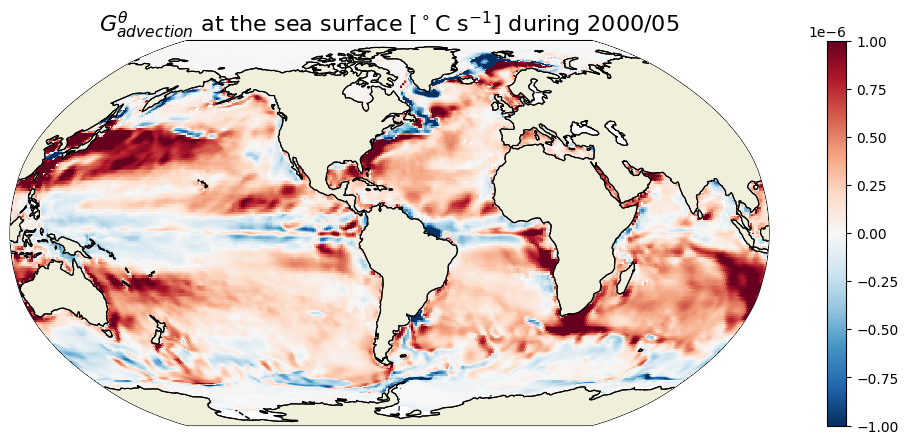

In [86]:
plt.figure(figsize=(15,5));

ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC,\
                              G_advection_compute(ds,ecco_monthly_mean_pickled,vol,time_isel=[curr_t_ind],k_isel=[0]),\
                              show_colorbar=True,
                              cmin=-1e-6, cmax=1e-6, cmap='RdBu_r', user_lon_0=-67, dx=0.2, dy=0.2)
plt.title(r'$G^\theta_{advection}$ at the sea surface [$^\circ$C s$^{-1}$] during ' + 
          str(tmp)[0:4] +'/' + str(tmp)[5:7], fontsize=16)
plt.show()

## Calculate tendency due to diffusive convergence ($G^{\theta}_\textrm{diffusion}$)

The relevant fields from the diagnostic output here are
- `DFxE_TH`: U Component Diffusive Flux of Potential Temperature (degC m^3/s)
- `DFyE_TH`: V Component Diffusive Flux of Potential Temperature (degC m^3/s)
- `DFrE_TH`: Vertical Diffusive Flux of Potential Temperature (Explicit part) (degC m^3/s)
- `DFrI_TH`: Vertical Diffusive Flux of Potential Temperature (Implicit part) (degC m^3/s)
> **Note**: Vertical diffusion has both an explicit (`DFrE_TH`) and an implicit (`DFrI_TH`) part.

As with advective fluxes, we use the xgcm `grid` object to calculate the convergence of horizontal heat diffusion.

In [87]:
# Set fluxes on land to zero (instead of NaN)
ds['DFxE_TH'] = ds.DFxE_TH.where(grid.hFacW.values > 0,0)
ds['DFyE_TH'] = ds.DFyE_TH.where(grid.hFacS.values > 0,0)
ds['DFrE_TH'] = ds.DFrE_TH.where(grid.hFacC.values > 0,0)
ds['DFrI_TH'] = ds.DFrI_TH.where(grid.hFacC.values > 0,0)

# tranpose dimensions
ds['DFrE_TH'] = ds.DFrE_TH.transpose('time','tile','k_l','j','i')
ds['DFrI_TH'] = ds.DFrI_TH.transpose('time','tile','k_l','j','i')

# re-chunk arrays for better performance
ds['DFxE_TH'] = ds['DFxE_TH'].chunk({'time':12,'k':-1,'tile':-1,'j':-1,'i_g':-1})
ds['DFyE_TH'] = ds['DFyE_TH'].chunk({'time':12,'k':-1,'tile':-1,'j_g':-1,'i':-1})
ds['DFrE_TH'] = ds['DFrE_TH'].chunk({'time':12,'k_l':-1,'tile':-1,'j':-1,'i':-1})
ds['DFrI_TH'] = ds['DFrI_TH'].chunk({'time':12,'k_l':-1,'tile':-1,'j':-1,'i':-1})

In [88]:
### Original code to compute G_diffusion is commented below
### (can use this if xgcm.diff_2d_vector is working properly
### and memory constraints allow)


# # compute horizontal components of flux divergence
# DFxyE_diff = grid.diff_2d_vector({'X' : ds.DFxE_TH, 'Y' : ds.DFyE_TH}, boundary = 'fill')

# # Convergence of horizontal diffusion (degC m^3/s)
# dif_hConvH = (-(DFxyE_diff['X'] + DFxyE_diff['Y']))

# # Convergence of vertical diffusion (degC m^3/s)
# dif_vConvH = grid.diff(DFrE_TH + DFrI_TH, 'Z', boundary='fill')

# # Sum horizontal and vertical convergences and divide by volume (degC/s)
# G_diffusion = (dif_hConvH + dif_vConvH)/vol


### End of original code block


# complete horizontal divergence calculation, 12 time indices (1 year) at a time

def G_diffusion_compute(ds,ecco_monthly_mean_pickled,vol,time_isel=None,k_isel=None):
    """Computes diffusion tendency for given time and k indices (k indices must be continuous, without gaps)"""

    if isinstance(time_isel,type(None)):
        time_isel = np.arange(0,ds.sizes['time'])
    if isinstance(k_isel,type(None)):
        k_isel = np.arange(0,ds.sizes['k'])

    if len(k_isel) > 1:
        if (np.nanmin(np.diff(np.asarray(k_isel))) < 1) or (np.nanmax(np.diff(np.asarray(k_isel))) > 1):
            raise ValueError('k_isel is not monotonically increasing or not continuous')        

    
    # re-open source dataset
    ecco_monthly_mean = pickle.loads(ecco_monthly_mean_pickled)
    
    ## compute horizontal convergence

    DFxE_TH = ds.DFxE_TH.isel(time=time_isel,k=k_isel)#.compute()
    DFyE_TH = ds.DFyE_TH.isel(time=time_isel,k=k_isel)#.compute()
    DFxyE_diff = diff_2d_flux_llc90({'X': DFxE_TH,\
                                     'Y': DFyE_TH})
    
    # Convergence of horizontal advection (degC m^3/s)
    dif_hConvH = (-(DFxyE_diff['X'] + DFxyE_diff['Y']))

    # transpose dimensions
    dif_hConvH = dif_hConvH.transpose('time','tile','k','j','i')
    
    # restore time coordinate to DataArray if needed (can be lost in xgcm.diff_2d_vector operation)
    dif_hConvH = dif_hConvH.assign_coords({'time':ds.time[time_isel].data})#.compute()
    
    ## compute vertical convergence
    
    if k_isel[-1] == ds.sizes['k']-1:
        DFrE_TH = ds.DFrE_TH.isel(time=time_isel,k_l=k_isel).pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=0)#.compute()
        DFrI_TH = ds.DFrI_TH.isel(time=time_isel,k_l=k_isel).pad(pad_width={'k_l':(0,1)},mode='constant',constant_values=0)#.compute()        
    else:
        DFrE_TH = ds.DFrE_TH.isel(time=time_isel,k_l=np.append(k_isel,k_isel[-1]+1))#.compute()
        DFrI_TH = ds.DFrI_TH.isel(time=time_isel,k_l=np.append(k_isel,k_isel[-1]+1))#.compute()        
    dif_vConvH = (DFrE_TH + DFrI_TH).diff('k_l').rename({'k_l':'k'})
    dif_vConvH = dif_vConvH.assign_coords({'k':ds.k[k_isel].data})
    
    # restore time coordinate to DataArray if needed (can be lost in xgcm.diff_2d_vector operation)
    dif_vConvH = dif_vConvH.assign_coords({'time':ds.time[time_isel].data})#.compute()
        
    ## Sum horizontal and vertical convergences and divide by volume (degC/s)
    G_diffusion = ((dif_hConvH + dif_vConvH)/vol)#.compute()
    
    # delete the variables where data was actually loaded into memory
    del DFxE_TH
    del DFyE_TH
    del dif_hConvH
    del DFrE_TH
    del DFrI_TH
    del dif_vConvH

    # close the original dataset where the fluxes were loaded from the source files (needed to clear the data from cache)
    ecco_monthly_mean.close()
    
    return G_diffusion

### Plot the time-mean $G^{\theta}_\textrm{diffusion}$

In [89]:
mem_avail = psutil.virtual_memory().available
print('Available memory:',mem_avail/(10**9),'GB')

# chunk size to use when computing time mean with monthly_tmean_aggregate (not the same as dask chunksize)
time_chunksize = int(np.round(mem_avail/(2**28)))
time_chunksize = np.fmin(np.fmax(time_chunksize,1),ds.sizes['time'])
print('Using time_chunksize =',time_chunksize)

Available memory: 301.363400704 GB
Using time_chunksize = 394


/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 16.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.

CPU times: user 20.2 s, sys: 5.32 s, total: 25.5 s
Wall time: 10min 7s


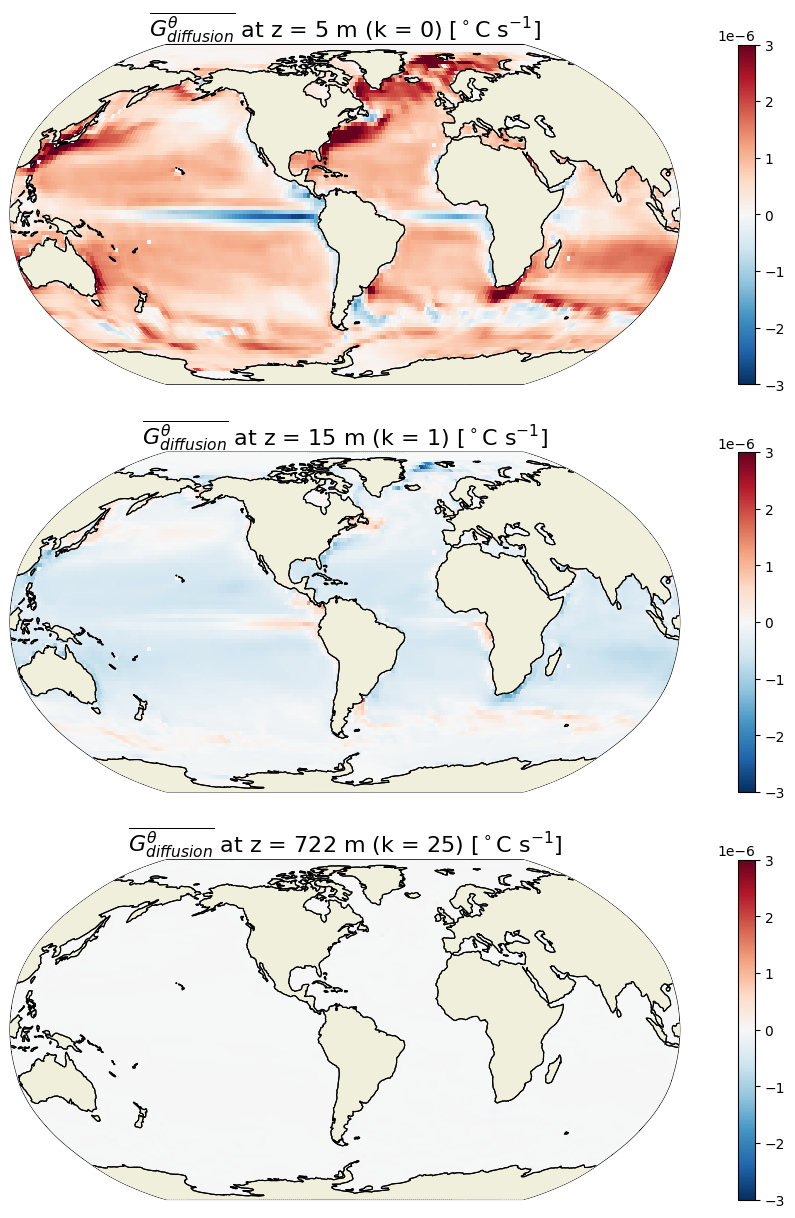

In [90]:
%%time 
plt.figure(figsize=(15,15))

for idx, k in enumerate([0,1,25]):
    p = ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC,\
                                      monthly_tmean_aggregate(G_diffusion_compute,\
                                                              ds,ecco_monthly_mean_pickled,vol,month_length_weights,\
                                                              time_chunksize=time_chunksize,k_isel=[k]),\
                                      show_colorbar=True,
                                      cmin=-3e-6, cmax=3e-6, cmap='RdBu_r', user_lon_0=-67, dx=2, dy=2, 
                                      subplot_grid=[3,1,idx+1]);
    p[1].set_title(r'$\overline{G^\theta_{diffusion}}$ at z = %i m (k = %i) [$^\circ$C s$^{-1}$]'\
                   %(np.round(-grid.Z[k].values),k), fontsize=16)

### Example $G^{\theta}_\textrm{diffusion}$ field at a particular time

In [91]:
curr_t_ind = 100
tmp = str(ds.time.values[curr_t_ind])
print(tmp)

2000-05-15T00:00:00.000000000


/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 15.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 15.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


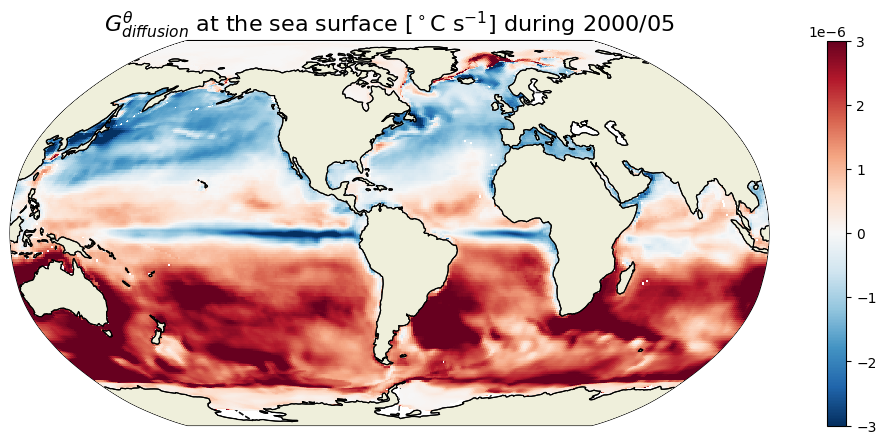

In [92]:
plt.figure(figsize=(15,5));

ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC,\
                              G_diffusion_compute(ds,ecco_monthly_mean_pickled,vol,time_isel=[curr_t_ind],k_isel=[0]),\
                              show_colorbar=True,
                              cmin=-3e-6, cmax=3e-6, cmap='RdBu_r', user_lon_0=-67, dx=0.2, dy=0.2)
plt.title(r'$G^\theta_{diffusion}$ at the sea surface [$^\circ$C s$^{-1}$] during ' + 
          str(tmp)[0:4] +'/' + str(tmp)[5:7], fontsize=16)
plt.show()

In [93]:
%%time

G_diffusion=G_diffusion_compute(ds,ecco_monthly_mean_pickled,vol,time_isel=None,k_isel=None)

CPU times: user 1.17 s, sys: 113 ms, total: 1.28 s
Wall time: 2.65 s


## Calculate tendency due to forcing ($G^{\theta}_\textrm{forcing}$)
Finally, we evaluate the local forcing term due to surface heat and geothermal fluxes.

### Surface heat flux
For the surface contribution, there are two relevant model diagnostics:
- `TFLUX`: total heat flux (match heat-content variations) (W/m^2)
- `oceQsw`: net Short-Wave radiation (+=down) (W/m^2)

#### Defining terms needed for evaluating surface heat forcing

In [94]:
Z = grid.Z.compute()
RF = np.concatenate([grid.Zp1.values[:-1],[np.nan]])

>**Note**: `Z` and `Zp1` are used in deriving surface heat penetration. MATLAB code uses `RF` from `mygrid` structure.

In [95]:
q1 = R*np.exp(1.0/zeta1*RF[:-1]) + (1.0-R)*np.exp(1.0/zeta2*RF[:-1])
q2 = R*np.exp(1.0/zeta1*RF[1:]) + (1.0-R)*np.exp(1.0/zeta2*RF[1:])

In [96]:
# Correction for the 200m cutoff
zCut = np.where(Z < -200)[0][0]
q1[zCut:] = 0
q2[zCut-1:] = 0

In [97]:
# Create xarray data arrays
q1 = xr.DataArray(q1,coords=[Z.k],dims=['k'])
q2 = xr.DataArray(q2,coords=[Z.k],dims=['k'])

#### Compute vertically penetrating flux
Given the penetrating nature of the shortwave term, to properly evaluate the local forcing term, `oceQsw` must be removed from `TFLUX` (which contains the net latent, sensible, longwave, and shortwave contributions) and redistributed vertically.

In [98]:
## Land masks
# Make copy of hFacC
mskC = grid.hFacC.copy(deep=True).compute()

# Change all fractions (ocean) to 1. land = 0
mskC.values[mskC.values>0] = 1

In [99]:
# Shortwave flux below the surface (W/m^2)
forcH_subsurf = ((q1*(mskC==1)-q2*(mskC.shift(k=-1)==1))*ds.oceQsw).transpose('time','tile','k','j','i')

In [100]:
# Surface heat flux (W/m^2)
forcH_surf = ((ds.TFLUX - (1-(q1[0]-q2[0]))*ds.oceQsw)\
              *mskC[0]).transpose('time','tile','j','i').assign_coords(k=0).expand_dims('k')

In [101]:
# Full-depth sea surface forcing (W/m^2)
forcH = xr.concat([forcH_surf,forcH_subsurf[:,:,1:]], dim='k').transpose('time','tile','k','j','i')

In [102]:
forcH

<xarray.DataArray (time: 394, tile: 13, k: 50, j: 90, i: 90)> Size: 17GB
dask.array<transpose, shape=(394, 13, 50, 90, 90), dtype=float64, chunksize=(12, 13, 49, 90, 90), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * k        (k) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
Attributes:
    long_name:              vertical open fraction of tracer grid cell
    coverage_content_type:  modelResult
    units:                  1
    comment:                Tracer grid cells may be fractionally closed in t...

### Geothermal flux

The geothermal flux contribution is not accounted for in any of the standard model diagnostics provided as output. Rather, this term, which is time invariant, is provided in the input file `geothermalFlux.bin` contained in the ancillary data archive. This archive can be downloaded from [PO.DAAC](https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_ANCILLARY_DATA_V4R4/ancillary_data_input_forcing_ECCO_V4r4.tar.gz), though accessing it there requires downloading a much larger tarball of files (~192 GB). So, for the time being, the `geothermalFlux.bin` file is also stored on the tutorial Github and can be downloaded [here](https://github.com/ECCO-GROUP/ECCO-v4-Python-Tutorial/raw/master/misc/geothermalFlux.bin).

> **Note**: The code cell below assumes `geothermalFlux.bin` has been placed in `~/Downloads`, or is in the cloned GitHub repository under `~/ECCO-v4-Python-Tutorial/misc` or `~/git_repos/ECCO-v4-Python-Tutorial/misc`. Change the directory `geoflx_dir` as needed.

In [103]:
# Load the geothermal heat flux using the routine 'read_llc_to_tiles'.
geoflx_filename = 'geothermalFlux.bin'
# if exists(join(user_home_dir,'Downloads',geoflx_filename)):
#     geoflx_dir = join(user_home_dir,'Downloads')
# elif exists(join(user_home_dir,'ECCO-v4-Python-Tutorial','misc',geoflx_filename)):
#     geoflx_dir = join(user_home_dir,'ECCO-v4-Python-Tutorial','misc')
# elif exists(join(user_home_dir,'git_repos','ECCO-v4-Python-Tutorial','misc',geoflx_filename)):
#     geoflx_dir = join(user_home_dir,'git_repos','ECCO-v4-Python-Tutorial','misc')
# elif exists(join(user_home_dir,'/efs/efs_ecco/ECCO/','V4/r5/input/input_forcing/other/',geoflx_filename)):
geoflx_dir = '/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6'
# else:
#     raise FilePathError('Can not locate '+geoflx_filename+' in default directories.\n'\
#                         +'Please specify geoflx_dir.')
# # geoflx_dir = join(user_home_dir,'Downloads')
geoflx = ecco.read_llc_to_tiles(geoflx_dir, 'geothermalFlux.bin')

load_binary_array: loading file /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/geothermalFlux.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4


The geothermal flux dataset needs to be saved as an xarray data array with the same format as the model output.

In [104]:
# Convert numpy array to an xarray DataArray with matching dimensions as the monthly mean fields
geoflx_llc = xr.DataArray(geoflx,coords={'tile': ecco_monthly_mean.tile.values,
                                         'j': ecco_monthly_mean.j.values,
                                         'i': ecco_monthly_mean.i.values},dims=['tile','j','i'])

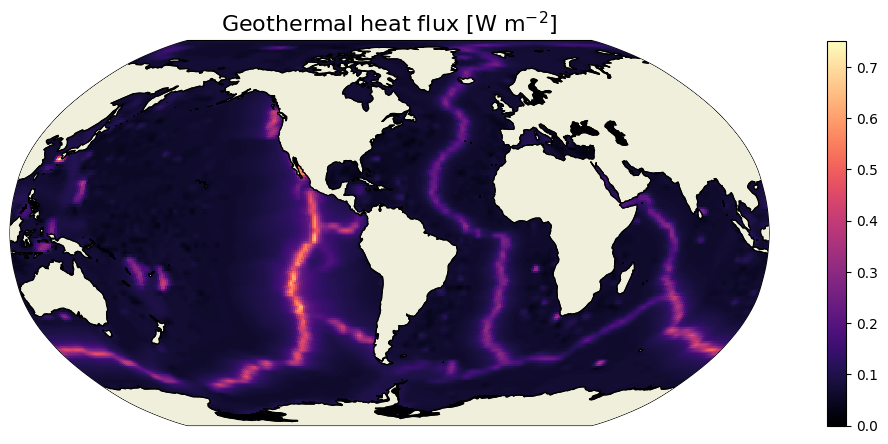

In [105]:
plt.figure(figsize=(15,5));

ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, geoflx_llc,show_colorbar=True,cmap='magma', 
                              user_lon_0=-67, dx=0.2, dy=0.2)
plt.title(r'Geothermal heat flux [W m$^{-2}$]', fontsize=16)
plt.show()

Geothermal flux needs to be a three dimensional field since the sources are distributed along the ocean floor at various depths. This requires a three dimensional mask.

In [106]:
# Create 3d bathymetry mask
mskC_shifted = mskC.shift(k=-1)

mskC_shifted.values[-1,:,:,:] = 0
mskb = mskC - mskC_shifted

# Create 3d field of geothermal heat flux
geoflx3d = geoflx_llc * mskb.transpose('k','tile','j','i')
GEOFLX = geoflx3d.transpose('k','tile','j','i')
GEOFLX.attrs = {'standard_name': 'GEOFLX','long_name': 'Geothermal heat flux','units': 'W/m^2'}

### Total forcing ($G^{\theta}_\textrm{forcing}$)

In [107]:
# Add geothermal heat flux to forcing field and convert from W/m^2 to degC/s
G_forcing = ((forcH + GEOFLX)/(rhoconst*c_p))/(grid.hFacC*grid.drF)

### Plot the time-mean $G^{\theta}_\textrm{forcing}$

In [108]:
G_forcing_mean = (G_forcing*month_length_weights).sum('time')

/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 80.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 80.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 80.86 

CPU times: user 12.1 s, sys: 5.76 s, total: 17.9 s
Wall time: 13min 22s


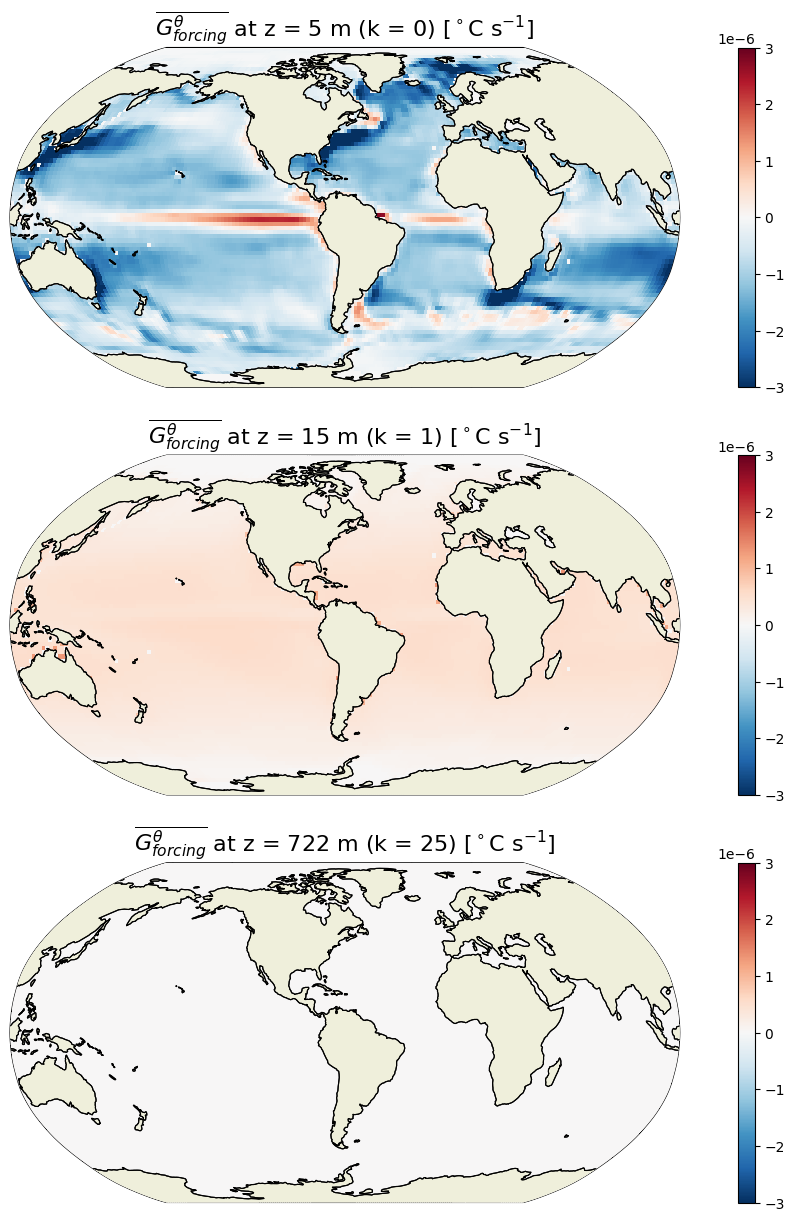

In [109]:
%%time

plt.figure(figsize=(15,15))

for idx, k in enumerate([0,1,25]):
    p = ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, G_forcing_mean.isel(k=k),show_colorbar=True,
                                      cmin=-3e-6, cmax=3e-6, cmap='RdBu_r', user_lon_0=-67, dx=2, dy=2, 
                                      subplot_grid=[3,1,idx+1]);
    p[1].set_title(r'$\overline{G^\theta_{forcing}}$ at z = %i m (k = %i) [$^\circ$C s$^{-1}$]'\
                   %(np.round(-grid.Z[k].values),k), fontsize=16)

$\overline{G^\theta_{forcing}}$ is focused at the sea surface and much smaller (essentially zero) at depth. $\overline{G^\theta_{forcing}}$ is negative for most of the ocean (away from the equator). The spatial pattern in the surface forcing is the same as for diffusion but with opposite sign (see maps for $\overline{G^\theta_{diffusion}}$ above). This makes sense as forcing is to a large extent balanced by diffusion within the mixed layer.

### Example $G^{\theta}_\textrm{forcing}$ field at a particular time

In [110]:
curr_t_ind = 100
tmp = str(G_forcing.time.values[curr_t_ind])
print(tmp)

2000-05-15T00:00:00.000000000


/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 80.85 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 80.85 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


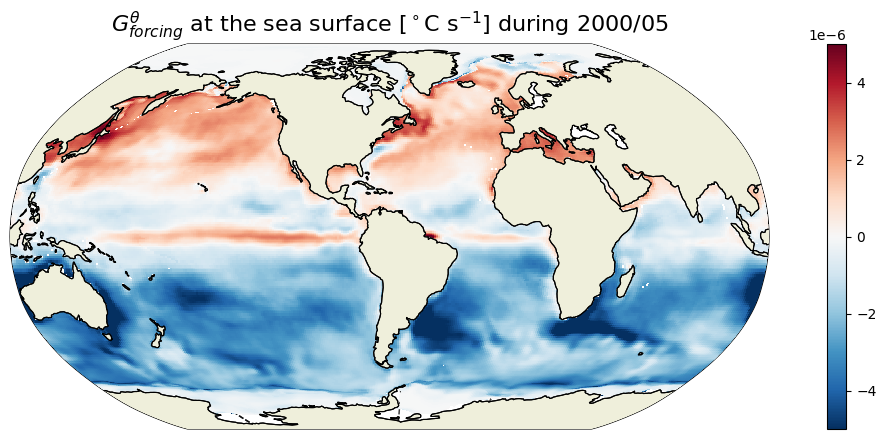

In [111]:
plt.figure(figsize=(15,5));

ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, G_forcing.isel(time=curr_t_ind,k=0),show_colorbar=True,
                              cmin=-5e-6, cmax=5e-6, cmap='RdBu_r', user_lon_0=-67, dx=0.2, dy=0.2)
plt.title(r'$G^\theta_{forcing}$ at the sea surface [$^\circ$C s$^{-1}$] during ' + 
          str(tmp)[0:4] +'/' + str(tmp)[5:7], fontsize=16)
plt.show()

## Save to dataset
Now that we have all the terms evaluated, let's save them to a dataset. Here are two examples:
- Zarr is a new format that is used for cloud storage.
- Netcdf is the more traditional format that most people are familiar with.

When saving this heat budget dataset, the zarr file is ~15 GB, while the NetCDF file is ~53 GB. So zarr can be more efficient for storage.

### Add all variables to a new dataset

In [112]:
G_total

<xarray.DataArray (time: 394, k: 50, tile: 13, j: 90, i: 90)> Size: 8GB
dask.array<truediv, shape=(394, 50, 13, 90, 90), dtype=float32, chunksize=(11, 50, 13, 90, 90), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB ...
    YC       (tile, j, i) float32 421kB ...
Attributes:
    long_name:              model seafloor depth below ocean surface at rest
    units:                  m
    coordinate:             XC YC
    coverage_content_type:  modelResult
    standard_name:          sea_floor_depth_below_geoid
    comment:                Model seafloor depth corresponds to mean ocean de...

In [113]:
##This code did not write the advection and diffusion term!!!!! I had to modify it to save them
### OKay, I'm gonna have to save the terms in separate files
varnames = ['G_forcing','G_advection', 'G_diffusion', 'G_total']

# G_total = G_total.transpose('time','tile','k','j','i')

# adv_diff_written = True

ds_budg = xr.Dataset(data_vars={})
for varname in varnames:
    # if varname not in globals():
        # create empty dask arrays for G_advection and G_diffusion (to be written later)
        # import dask.array as da
        # ds_budg[varname] = (['time','tile','k','j','i'],\
        #                     da.empty((ds.sizes['time'],13,50,90,90),dtype='float32',\
        #                             chunks=(1,13,50,90,90)))
        # # adv_diff_written = False
    # else:
    ds_budg[varname] = globals()[varname].chunk(chunks={'time':1,'tile':13,'k':50,'j':90,'i':90})        

In [114]:
# # Add surface forcing (degC/s)
# ds_budg['Qnet'] = ((forcH /(rhoconst*c_p))\
#                   /(ecco_grid.hFacC*ecco_grid.drF)).chunk(chunks={'time':1,'tile':13,'k':50,'j':90,'i':90})

In [115]:
# # Add shortwave penetrative flux (degC/s)
# #Since we only are interested in the subsurface heat flux we need to zero out the top cell
# SWpen = ((forcH_subsurf /(rhoconst*c_p))/(ecco_grid.hFacC*ecco_grid.drF)).where(forcH_subsurf.k>0).fillna(0.)
# ds_budg['SWpen'] = SWpen.where(ecco_grid.hFacC>0).chunk(chunks={'time':1,'tile':13,'k':50,'j':90,'i':90})

> **Note**: `Qnet` and `SWpen` are included in `G_forcing` and are not necessary to close the heat budget. 

In [116]:
ds_budg.time.encoding = {}
ds_budg = ds_budg.reset_coords(drop=True)

In [117]:
ds_budg

<xarray.Dataset> Size: 41GB
Dimensions:      (tile: 13, j: 90, i: 90, time: 394, k: 50)
Coordinates:
  * tile         (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j            (j) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * i            (i) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time         (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * k            (k) int32 200B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
Data variables:
    G_forcing    (time, tile, k, j, i) float64 17GB dask.array<chunksize=(1, 13, 50, 90, 90), meta=np.ndarray>
    G_advection  (time, tile, k, j, i) float32 8GB dask.array<chunksize=(1, 13, 50, 90, 90), meta=np.ndarray>
    G_diffusion  (time, tile, k, j, i) float32 8GB dask.array<chunksize=(1, 13, 50, 90, 90), meta=np.ndarray>
    G_total      (time, k, tile, j, i) float32 8GB dask.array<chunksize=(1, 50, 13, 90, 90), meta=np.ndarray>

/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 80.98 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


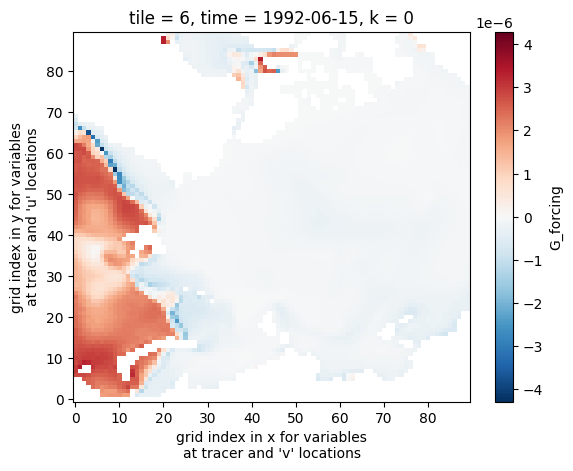

In [118]:
ds_budg.G_forcing.isel(time=5, k=0, tile=6).plot()

In [119]:
# save_dir is set to ~/Downloads below;
# change if you want to save somewhere else
save_dir = '/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/budgH'

# first query how much storage is free
# the zarr file will occupy ~15 GB, so require 20 GB free storage as a buffer

import shutil
free_storage = shutil.disk_usage(save_dir).free
print(f'Free storage: {free_storage/(10**9)} GB')

# query how much memory is available
# (influences how this large archive will be computed and stored)
mem_avail = psutil.virtual_memory().available
print('Available memory:',mem_avail/(10**9),'GB')

Free storage: 63172.507598848 GB
Available memory: 308.74013696 GB


In [120]:
from dask.diagnostics import ProgressBar

In [121]:
for var in ds_budg.data_vars:
    if ds_budg[var].dtype == 'float64':
        ds_budg[var] = ds_budg[var].astype('float32')

ds_budg

<xarray.Dataset> Size: 33GB
Dimensions:      (tile: 13, j: 90, i: 90, time: 394, k: 50)
Coordinates:
  * tile         (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j            (j) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * i            (i) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time         (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * k            (k) int32 200B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
Data variables:
    G_forcing    (time, tile, k, j, i) float32 8GB dask.array<chunksize=(1, 13, 50, 90, 90), meta=np.ndarray>
    G_advection  (time, tile, k, j, i) float32 8GB dask.array<chunksize=(1, 13, 50, 90, 90), meta=np.ndarray>
    G_diffusion  (time, tile, k, j, i) float32 8GB dask.array<chunksize=(1, 13, 50, 90, 90), meta=np.ndarray>
    G_total      (time, k, tile, j, i) float32 8GB dask.array<chunksize=(1, 50, 13, 90, 90), meta=np.ndarray>

In [122]:
ds_budg.nbytes*1e-9

33.190564124000005

### Map of residuals

In [123]:
rhs = ds_budg.G_advection + ds_budg.G_diffusion + ds_budg.G_forcing
rhs

<xarray.DataArray (time: 394, tile: 13, k: 50, j: 90, i: 90)> Size: 8GB
dask.array<add, shape=(394, 13, 50, 90, 90), dtype=float32, chunksize=(1, 13, 50, 90, 90), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-15 1992-02-15 ... 2024-10-15
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Attributes:
    coordinate:             YC XC
    coverage_content_type:  modelResult
    long_name:              vertical open fraction of tracer grid cell
    units:                  1
    comment:                Tracer grid cells may be fractionally closed in t...

In [126]:
res = ((rhs-G_total).sum(dim='k')*month_length_weights).sum(dim='time').compute()
res

/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 132.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-03-06 15:42:50,538 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:35319
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/comm/core.py", line 342, in connect
    comm = await wait_for(
           ^^^^^^^^^^^^^^^
  File "/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/distributed/utils.py", line 1928, in wait_

<xarray.DataArray (tile: 13, j: 90, i: 90)> Size: 421kB
array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 2.81843349e-09,  4.38355308e-09,  5.00824271e-09, ...,
          3.53600171e-09,  3.05606385e-09,  2.29281927e-09],
        [ 2.12666418e-09,  3.04121262e-09,  3.35113093e-09, ...,
          3.07997450e-09,  2.80791035e-09,  2.36942466e-09],
        [ 1.56367186e-09,  2.22381757e-09,  2.56971333e-09, ...,
          2.51856136e-09,  2.23192131e-09,  2.05150030e-09]],

       [[ 1.18801147e-09,  1.46564272e-09,  1.74258474e-09, ...,
          2.08403250e-09,  1.82598558e-09,  1.96359817e-09],
        [ 7.53433760e-10,  2.58852495e-10,  9.52331547e-11, ...,
          1.64864566e-09,  1.53516400e-09,  1.93628669e-09],
        [-1.03425002e-09, -2.05008188e-09, -1.43663392e-09, ...,
          1.63699276e-09,  1.64167702e-09,  1.95583016e-09],
...
          6.25601793e-10,  5.16413579e-10,  1.03666409e-10],
        [ 7.05847381e-09,  9.08861786e-09,  1.21878792e-08, ...,
          5.43702861e-10,  7.33949790e-10,  1.94370742e-10],
        [ 4.90574159e-09,  7.69905295e-09,  1.15667955e-08, ...,
          2.87530000e-11,  9.09062159e-10,  7.32362615e-10]],

       [[-1.78016268e-09, -6.30216768e-10,  1.69686842e-09, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 8.02867994e-10,  1.74904446e-09,  3.89868982e-09, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 3.48608076e-09,  4.22350865e-09,  6.11673956e-09, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 2.51363375e-10,  9.09206044e-10,  1.61341340e-09, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 6.40328679e-10,  1.50629997e-09,  2.27886687e-09, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 9.74427650e-10,  1.58457425e-09,  2.03532213e-09, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]],
      shape=(13, 90, 90), dtype=float32)
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
Attributes:
    coverage_content_type:  modelResult
    standard_name:          sea_floor_depth_below_geoid
    c_grid_axis_shift:      0.5

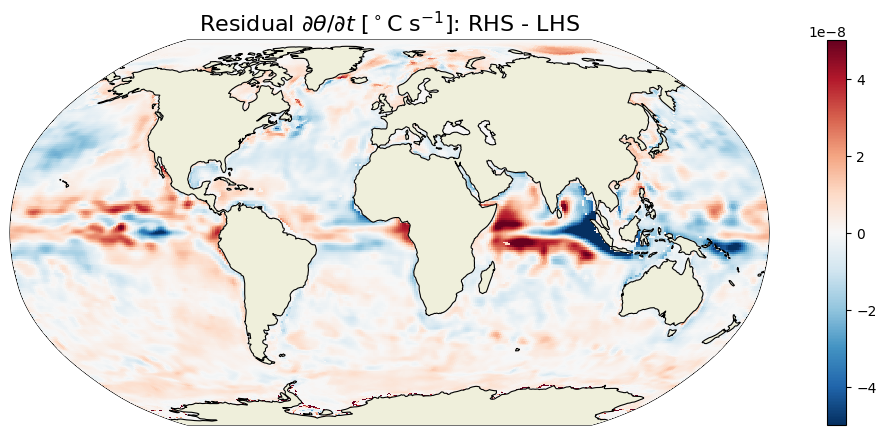

In [130]:
plt.figure(figsize=(15,5))
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, res,
                              cmin=-5e-8, cmax=5e-8, show_colorbar=True, cmap='RdBu_r',dx=0.2, dy=0.2)
plt.title(r'Residual $\partial \theta / \partial t$ [$^\circ$C s$^{-1}$]: RHS - LHS', fontsize=16)
plt.show()

/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in add
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered 

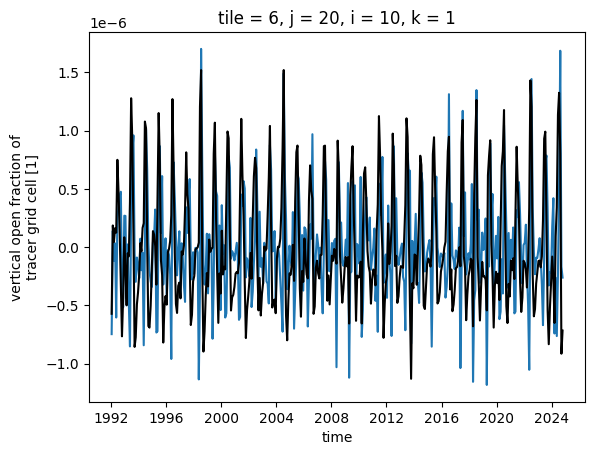

In [108]:
plt.figure()

(ds_budg.G_forcing+ds_budg.G_advection+ds_budg.G_diffusion - ds_budg.G_total).isel(i=10, j=20, k=1, tile=6).plot()
(ds_budg.G_forcing+ds_budg.G_advection+ds_budg.G_diffusion).isel(i=10, j=20, k=1, tile=6).plot(c='k')

In [127]:
# # to save budget as netcdf, set save_netcdf = True
# save_netcdf = True

# # encoding = {var: {"dtype": "float32", "zlib": True, "complevel": 1} for var in ds_budg.data_vars}

# # the netcdf file will occupy ~53 GB, so require 60 GB free storage as a buffer
# if save_netcdf:
#     if free_storage >= 60*(10**9):
#         with ProgressBar():
#             ds_budg.to_netcdf(join(save_dir,'eccov4r6_budg_heat_terms.nc'), compute=True)
#     else:
#         print('Insufficient storage to save global budget terms to disk as netcdf')

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 83.17 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
